## Xenium data



1. Load libraries and paths.
2. Load 5K and V1 SpatialData objects.
3. Compare core QC distributions with overlaid histograms.
4. Build overlap-gene subset shared by both panels.
5. Compute detection and expression statistics on overlap genes.
6. Run optional downstream analyses (UMAP/Leiden + spatial plots).

In [ ]:
from pathlib import Path

import anndata as ad
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import spatialdata as sd
import spatialdata_io
import squidpy as sq
from pandas.util import hash_pandas_object
from scipy.sparse import issparse
from scipy.stats import pearsonr
from spatialdata.models import PointsModel
from spatialdata.transformations import get_transformation, set_transformation

# Base directories for the folders containing the data for the two versions of the Xenium platform

# BASE_5K = Path("C://Users//ntpar//Downloads//Xenium_Prime_Human_Lung_Cancer_FFPE_xe_outs")
BASE_5K = Path("C://Users//ntpar//Downloads//Xenium_V1_Human_Lung_Cancer_FFPE_xe_outs")


# BASE_5K = Path("C:/Users/ntpar/Downloads/Xenium_Prime_Human_Ovary_Cancer_FF_xe_outs")
# BASE_V1 = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Ovary_Cancer_FF_xe_outs")


# Extra lung panel I
# BASE_V1 = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Lung_Cancer_Addon_FFPE_xe_outs")

# Extra lung panel II
BASE_V1 = Path("C:/Users/ntpar/Downloads/Xenium_V1_humanLung_Cancer_FFPE_xe_outs")

: 

## 1) SpatialData loading

In [158]:
# Not loading in morphology for now, to save memory
sdata_5k = spatialdata_io.xenium(BASE_5K, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
adata_5k = sdata_5k.tables["table"]
sdata_5k

C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\1552705079.py:2: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_5k = spatialdata_io.xenium(BASE_5K, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\1552705079.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_5k = spatialdata_io.xenium(BASE_5K, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (278659, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (278659, 289)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [159]:
sdata_v1 = spatialdata_io.xenium(BASE_V1, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
adata_v1 = sdata_v1.tables["table"]
sdata_v1

C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\3293270891.py:1: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_v1 = spatialdata_io.xenium(BASE_V1, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\3293270891.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_v1 = spatialdata_io.xenium(BASE_V1, nucleus_labels=False, cell_labels=False, morphology_mip=False, transcripts=False, morphology_focus=False)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (162254, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (162254, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (156628, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162254, 377)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [160]:
#Stable raw references so re-running filtering cells is threshold-dependent
sdata_5k_raw = sdata_5k
sdata_v1_raw = sdata_v1
adata_5k_raw = sdata_5k_raw.tables["table"]
adata_v1_raw = sdata_v1_raw.tables["table"]


## QC: Filtering cells & transcripts

### Calculating extra rows 

sc.pp.calculate_qc_metrics calculates these variables: 
- 'n_genes_by_counts',
- 'log1p_n_genes_by_counts', 
- 'total_counts', 
- 'log1p_total_counts', 
- 'pct_counts_in_top_50_genes', 
- 'pct_counts_in_top_100_genes', 
- 'pct_counts_in_top_200_genes', 
- 'pct_counts_in_top_289_genes'

In [168]:
adata_5k = sdata_5k.tables["table"]
pt = tuple((50, 100, 200, 250))
sc.pp.calculate_qc_metrics(adata_5k, inplace=True, percent_top = pt)
adata_5k 

adata_v1 = sdata_v1.tables["table"]
pt = tuple((50, 100, 200, 250))
sc.pp.calculate_qc_metrics(adata_v1, inplace=True, percent_top = pt)
adata_v1

AnnData object with n_obs × n_vars = 162254 × 377
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_250_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [169]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ACE,ENSG00000159640,Gene Expression,,46138,0.380860,0.322706,83.442846,106130.0,11.572430
ACE2,ENSG00000130234,Gene Expression,,19415,0.114976,0.108833,93.032703,32039.0,10.374741
ACKR1,ENSG00000213088,Gene Expression,,12394,0.156356,0.145274,95.552270,43570.0,10.682147
ADAM17,ENSG00000151694,Gene Expression,,78571,0.456350,0.375933,71.803889,127166.0,11.753257
ADAM28,ENSG00000042980,Gene Expression,,40312,0.258075,0.229583,85.533573,71915.0,11.183254
...,...,...,...,...,...,...,...,...,...
VSIG4,ENSG00000155659,Gene Expression,,26062,0.246064,0.219990,90.647350,68568.0,11.135596
VWF,ENSG00000110799,Gene Expression,,52119,0.791674,0.583150,81.296495,220607.0,12.304143
WFS1,ENSG00000109501,Gene Expression,,41515,0.217815,0.197058,85.101863,60696.0,11.013650
WNT2,ENSG00000105989,Gene Expression,,10009,0.043738,0.042809,96.408155,12188.0,9.408289


In [170]:
adata_5k.obs 

,cell_id,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count,region,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_250_genes
0,aaaadcac-1,76.539847,316.208374,4134.647461,6.863750,5.0,1.0,cell_circles,25,3.258097,35.0,3.583519,100.000000,100.0,100.0,100.0
1,aaaaieak-1,34.002657,316.866608,4125.147949,12.688907,6.0,1.0,cell_circles,33,3.526361,61.0,4.127134,100.000000,100.0,100.0,100.0
2,aaaanbhm-1,128.514692,316.900940,4111.290527,30.028907,5.0,1.0,cell_circles,66,4.204693,292.0,5.680172,94.520548,100.0,100.0,100.0
3,aaaankfe-1,85.796878,335.271484,4117.183594,44.975627,5.0,1.0,cell_circles,64,4.174387,303.0,5.717028,95.379538,100.0,100.0,100.0
4,aaaankfi-1,63.038127,342.718292,4123.146973,14.540313,5.0,1.0,cell_circles,24,3.218876,32.0,3.496508,100.000000,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278654,oikpbgok-1,74.327190,3647.097412,3955.416992,19.146251,6.0,1.0,cell_circles,55,4.025352,139.0,4.941642,96.402878,100.0,100.0,100.0
278655,oikpdjia-1,44.478908,3651.639893,3956.491943,16.617501,5.0,1.0,cell_circles,43,3.784190,122.0,4.812184,100.000000,100.0,100.0,100.0
278656,oikpehhe-1,143.461411,3653.819824,3902.810303,39.918126,5.0,1.0,cell_circles,44,3.806662,114.0,4.744932,100.000000,100.0,100.0,100.0
278657,oikpjbjc-1,49.175158,3655.821777,3898.566162,4.560781,6.0,1.0,cell_circles,14,2.708050,16.0,2.833213,100.000000,100.0,100.0,100.0


### Cell filtering
- We filter the cells with less than the threshold number of transcripts
- We also filter the transcripts with a QV < 20 out
    - What's nice is that these transcripts are automatically already not included in the table for the cells, so we don't have to change anything about total_counts etc.
    - The qv column in Xenium’s transcript table is a Phred-scaled “Q-Score” that represents confidence in each decoded transcript call. Conceptually, it’s a rescaling of an estimated error probability: higher qv means higher probability that the transcript identity/call is correct

In [171]:
threshold = 40
genes_threshold = 5

mask_5k = (
    (adata_5k_raw.obs["total_counts"] >= threshold)
    & (adata_5k_raw.obs["n_genes_by_counts"] > genes_threshold)
)
mask_v1 = (
    (adata_v1_raw.obs["total_counts"] >= threshold)
    & (adata_v1_raw.obs["n_genes_by_counts"] > genes_threshold)
)

adata_5k_f = adata_5k_raw[mask_5k].copy()
adata_v1_f = adata_v1_raw[mask_v1].copy()

sdata_5k.tables["table"] = adata_5k_f
sdata_v1.tables["table"] = adata_v1_f

In [172]:
adata_5k = sdata_5k.tables["table"]
adata_v1 = sdata_v1.tables["table"]

print(f"Original 5K data shape: {adata_5k_raw.obs.shape}")
print(f"Filtered 5K data shape: {adata_5k.obs.shape}")
print(f"There were {adata_5k_raw.obs.shape[0] - adata_5k.obs.shape[0]} cells filtered out from the 5K dataset.")

print(f"Original V1 data shape: {adata_v1_raw.obs.shape}")
print(f"Filtered V1 data shape: {adata_v1.obs.shape}")
print(f"There were {adata_v1_raw.obs.shape[0] - adata_v1.obs.shape[0]} cells filtered out from the V1 dataset.")

Original 5K data shape: (278659, 16)
Filtered 5K data shape: (188797, 16)
There were 89862 cells filtered out from the 5K dataset.
Original V1 data shape: (162254, 16)
Filtered V1 data shape: (93502, 16)
There were 68752 cells filtered out from the V1 dataset.


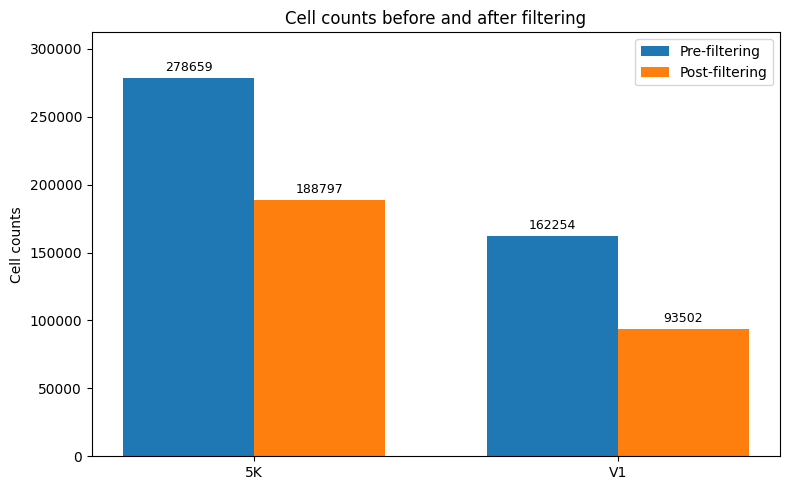

In [173]:
# Bar plot: number of cells before and after filtering (5K vs V1)
pre_5k = adata_5k_raw.n_obs
pre_v1 = adata_v1_raw.n_obs
post_5k = adata_5k.n_obs
post_v1 = adata_v1.n_obs

labels = ["5K", "V1"]
pre_counts = [pre_5k, pre_v1]
post_counts = [post_5k, post_v1]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
pre_bars = ax.bar(x - width / 2, pre_counts, width, label="Pre-filtering")
post_bars = ax.bar(x + width / 2, post_counts, width, label="Post-filtering")

ax.set_ylabel("Cell counts")
ax.set_title("Cell counts before and after filtering")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add value labels above bars
for bars in [pre_bars, post_bars]:
    for bar in bars:
        height = int(bar.get_height())
        ax.annotate(
            f"{height}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_ylim(0, max(pre_counts + post_counts) * 1.12)
plt.tight_layout()
plt.show()

### Distributions of entire panels

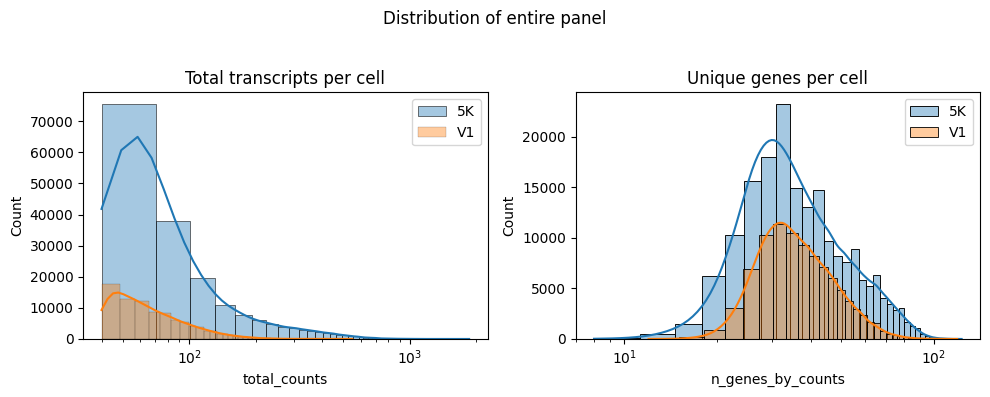

In [174]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribution of entire panel")

# 1) Total transcripts per cell
axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata_5k.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[0],
)
sns.histplot(
    adata_v1.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[0],
)
axs[0].set_xscale("log")
axs[0].legend()

# 2) Unique genes per cell
axs[1].set_title("Unique genes per cell")
sns.histplot(
    adata_5k.obs["n_genes_by_counts"],
    kde=True,
    bins=35,
    alpha=0.4,
    label="5K",
    ax=axs[1],
)
sns.histplot(
    adata_v1.obs["n_genes_by_counts"],
    kde=True,
    bins=35,
    alpha=0.4,
    label="V1",
    ax=axs[1],
)
axs[1].set_xscale("log")
axs[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Using only overlapping genes

In [175]:
# Promote filtered SpatialData objects, keep only overlapping genes, and refresh QC
overlap_genes = sorted(set(adata_5k.var_names).intersection(set(adata_v1.var_names)))
print("Number of overlapping genes:", len(overlap_genes))

overlap_genes_idx = pd.Index(overlap_genes)
adata_5k = sdata_5k.tables["table"][:, overlap_genes_idx].copy()
adata_v1 = sdata_v1.tables["table"][:, overlap_genes_idx].copy()

assert adata_5k.var_names.equals(adata_v1.var_names)
assert set(adata_5k.var_names) == set(overlap_genes)

pt = tuple((25, 50, 100, 150))
sc.pp.calculate_qc_metrics(adata_5k, inplace=True, percent_top=pt)
sc.pp.calculate_qc_metrics(adata_v1, inplace=True, percent_top=pt)

# replace tables so downstream sdata uses the filtered, overlap-only AnnData
sdata_5k.tables["table"] = adata_5k
sdata_v1.tables["table"] = adata_v1

print(f"5K overlap-only shape: {adata_5k.shape}")
print(f"V1 overlap-only shape: {adata_v1.shape}")

Number of overlapping genes: 156
5K overlap-only shape: (188797, 156)
V1 overlap-only shape: (93502, 156)


### (Optional?) Removing transcripts (filtered and <QV)
(Optional?): Are we using the transcripts?

The first cell makes sure we're only using the transcripts of the cells that we have filtered 
The second makes sure we remove the QV<20 

In [ ]:
def fast_filter_table_and_transcripts(sdata, adata_f, transcripts_key="transcripts"):
    # We copy the points & shapes dicts so we don't modify the data in-place
    points = dict(sdata.points)
    shapes = dict(sdata.shapes)

    tx = points[transcripts_key]
    use_cell_merge = False

    # We filter out the transcripts by merging with the filtered cells in the filtered adata_f
    if "cell_id" in tx.columns and "cell_id" in adata_f.obs.columns:
        tx_cell = tx["cell_id"].astype(str)
        if isinstance(tx_cell, dd.Series):
            n_non_empty = int((tx_cell.str.len() > 0).sum().compute())
        else:
            n_non_empty = int((tx_cell.str.len() > 0).sum())
        use_cell_merge = n_non_empty > 0

    if use_cell_merge:
        kept_cells = adata_f.obs[["cell_id"]].copy()
        kept_cells["cell_id"] = kept_cells["cell_id"].astype(str)
        kept_cells_dd = dd.from_pandas(kept_cells, npartitions=1)
        tx = tx.assign(cell_id=tx["cell_id"].astype(str))
        tx_f = tx.merge(kept_cells_dd, on="cell_id", how="inner")
    else:
        print("Warning: transcript cell_id values are empty/unusable; skipping transcript-to-cell merge.")
        tx_f = tx

    tx_f = PointsModel.parse(tx_f)
    t = get_transformation(points[transcripts_key], to_coordinate_system="global")
    set_transformation(tx_f, t, to_coordinate_system="global")
    points[transcripts_key] = tx_f

    if "cell_circles" in shapes and getattr(shapes["cell_circles"].index, "dtype", None) == object:
        kept_idx = set(adata_f.obs["cell_id"].astype(str)) if "cell_id" in adata_f.obs.columns else set()
        shapes["cell_circles"] = shapes["cell_circles"].loc[
            shapes["cell_circles"].index.intersection(kept_idx)
        ]

    return sd.SpatialData(
        images=dict(sdata.images),
        labels=dict(sdata.labels),
        points=points,
        shapes=shapes,
        tables={**dict(sdata.tables), "table": adata_f},
        attrs=sdata.attrs,
    )

In [ ]:
sdata_5k_f = fast_filter_table_and_transcripts(sdata_5k_raw, adata_5k_f, transcripts_key="transcripts")
sdata_v1_f = fast_filter_table_and_transcripts(sdata_v1_raw, adata_v1_f, transcripts_key="transcripts")

In [12]:
tx_5k = sdata_5k_f.points["transcripts"]
tx_5k_f = tx_5k[tx_5k["qv"] >= 20]

tx_v1 = sdata_v1_f.points["transcripts"]
tx_v1_f = tx_v1[tx_v1["qv"] >= 20]

n_before_5k = tx_5k.shape[0].compute()
n_after_5k = tx_5k_f.shape[0].compute()
if n_before_5k > 0:
    print(f"5K: Removed {n_before_5k - n_after_5k:,} transcripts ({(n_before_5k - n_after_5k)/n_before_5k:.2%}).")
else:
    print("5K: No transcripts available before QV filtering.")

n_before_v1 = tx_v1.shape[0].compute()
n_after_v1 = tx_v1_f.shape[0].compute()
if n_before_v1 > 0:
    print(f"V1: Removed {n_before_v1 - n_after_v1:,} transcripts ({(n_before_v1 - n_after_v1)/n_before_v1:.2%}).")
else:
    print("V1: No transcripts available before QV filtering.")

# Persist filtered transcripts in the filtered SpatialData objects used downstream
tx_5k_f = PointsModel.parse(tx_5k_f)
t_5k = get_transformation(sdata_5k_f.points["transcripts"], to_coordinate_system="global")
set_transformation(tx_5k_f, t_5k, to_coordinate_system="global")
sdata_5k_f.points["transcripts"] = tx_5k_f

tx_v1_f = PointsModel.parse(tx_v1_f)
t_v1 = get_transformation(sdata_v1_f.points["transcripts"], to_coordinate_system="global")
set_transformation(tx_v1_f, t_v1, to_coordinate_system="global")
sdata_v1_f.points["transcripts"] = tx_v1_f

print("Persisted qv>=20 filtered transcripts into sdata_5k_f and sdata_v1_f.")

5K: Removed 27,768,458 transcripts (15.65%).
V1: Removed 1,183,011 transcripts (3.69%).


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


Persisted qv>=20 filtered transcripts into sdata_5k_f and sdata_v1_f.


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


## Plotting data
For total transcripts per cell, I use `total_counts < 800` to improve readability, since there are relatively few entries above that range.

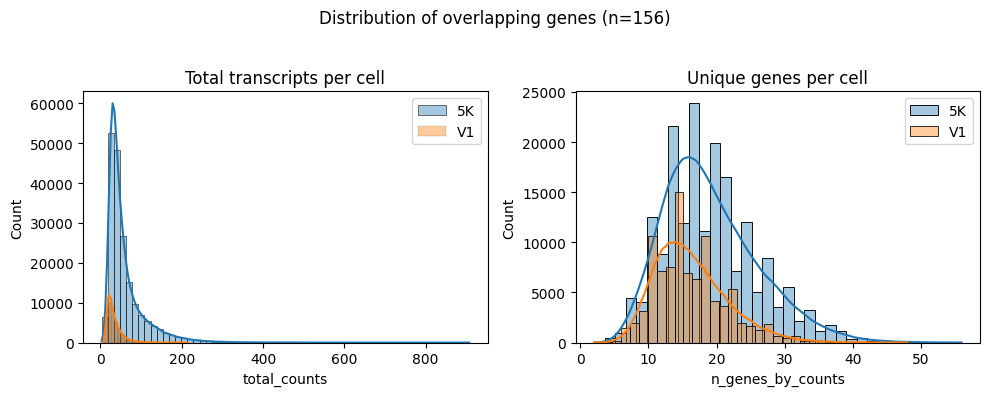

In [176]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f"Distribution of overlapping genes (n={len(overlap_genes)})")

# 1) Total transcripts per cell
axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata_5k.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[0],
)
sns.histplot(
    adata_v1.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[0],
)
axs[0].legend()

# 2) Unique genes per cell
axs[1].set_title("Unique genes per cell")
sns.histplot(
    adata_5k.obs["n_genes_by_counts"],
    kde=True,
    bins=35,
    alpha=0.4,
    label="5K",
    ax=axs[1],
)
sns.histplot(
    adata_v1.obs["n_genes_by_counts"],
    kde=True,
    bins=35,
    alpha=0.4,
    label="V1",
    ax=axs[1],
)
axs[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### How I read the Quality Control plot above
The overlaid histograms compare per-cell distributions between 5K and V1 using all genes.
- A right-shift in **total_counts** or **n_genes_by_counts** suggests higher effective sensitivity.

## Per-gene statistics

### Interpreting the data
Here is what the `adata_5k.var` columns mean. The first three come from the Xenium cell-feature matrix feature annotations; the rest are per-gene QC metrics added by `sc.pp.calculate_qc_metrics`.
- `gene_ids`: Ensembl gene ID for the feature (matches column 1 of Xenium `cell_feature_matrix/features.tsv.gz`).
- `feature_types`: Feature category (e.g., Gene Expression; corresponds to column 3 of `features.tsv.gz`).
- `genome`: Genome/reference label stored in 10x matrices (often empty or a single reference label for Xenium targeted panels).
- `n_cells_by_counts`: Number of cells with nonzero counts for the gene (detected in at least one transcript).
- `mean_counts`: Mean expression across all cells (including zeros) from the matrix used for QC (`adata.X` unless another layer/raw was specified).
- `log1p_mean_counts`: `log(1 + mean_counts)`; populated because `calculate_qc_metrics(log1p=True)` is default.
- `pct_dropout_by_counts`: Percentage of cells where the gene has zero counts (dropout rate).
- `total_counts`: Sum of counts for the gene across all cells (total transcripts assigned to that gene in the matrix).
- `log1p_total_counts`: `log(1 + total_counts)`; also added due to `log1p=True`.

In [177]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ACE2,ENSG00000130234,Gene Expression,,19019,0.167524,0.154885,89.926217,31628.0,10.361830
ACKR1,ENSG00000213088,Gene Expression,,9247,0.202027,0.184009,95.102147,38142.0,10.549097
ADAM28,ENSG00000042980,Gene Expression,,35636,0.349227,0.299532,81.124700,65933.0,11.096410
ADAMTS1,ENSG00000154734,Gene Expression,,34548,0.592912,0.465564,81.700980,111940.0,11.625728
ADGRL4,ENSG00000162618,Gene Expression,,18531,0.159155,0.147691,90.184696,30048.0,10.310585
...,...,...,...,...,...,...,...,...,...
TREM2,ENSG00000095970,Gene Expression,,9386,0.081098,0.077977,95.028523,15311.0,9.636392
UBE2C,ENSG00000175063,Gene Expression,,9745,0.137206,0.128574,94.838371,25904.0,10.162191
UPK3B,ENSG00000243566,Gene Expression,,6110,0.038401,0.037682,96.763720,7250.0,8.888895
VSIG4,ENSG00000155659,Gene Expression,,22333,0.339190,0.292065,88.170893,64038.0,11.067247


## Per-gene detection

Each point is one overlap gene after applying the >=1% expressing-in-either-panel filter.
- Left plot (detection sensitivity): 
    - Each point represents a gene
    - x-axis is the % of cells that have a > 0 count for custom V1 panel
    - y-axis is the % of cells that have a > 0 count for 5K panel
- Right panel (magnitude when detected): 
    - Each point is a gene again, but we only look at cells where the gene was detected (count > 0), and average raw counts across those cells
    - x-axis is the mean raw counts among expressing V1 cells (`total_counts / n_cells_by_counts`)
    - y-axis is the mean raw counts among expressing 5K cells.

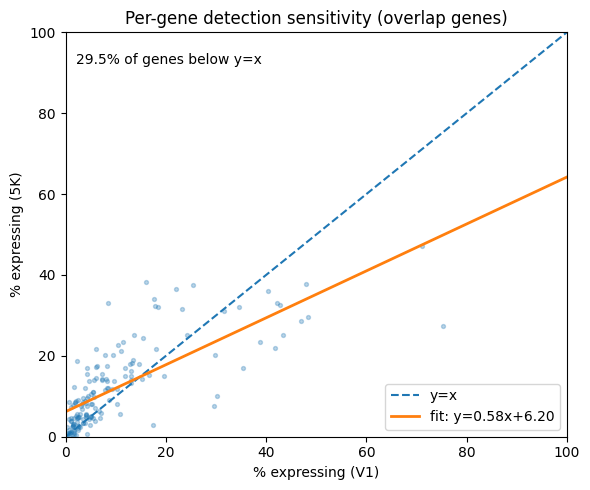

In [ ]:
min_pct = 0.0  # Minimum % expressing to include in the plot
d = pd.DataFrame(index=adata_5k.var_names)
d["pct_expressing_5k"] = 100 - adata_5k.var["pct_dropout_by_counts"]
d["pct_expressing_v1"] = 100 - adata_v1.var["pct_dropout_by_counts"]

# Apply expressing filter in either panel
mask = (d["pct_expressing_5k"] >= min_pct) | (d["pct_expressing_v1"] >= min_pct)
d = d.loc[mask].copy()

# Per-gene detection sensitivity (% expressing)
x = d["pct_expressing_v1"].to_numpy()
y = d["pct_expressing_5k"].to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(x, y, s=8, alpha=0.3)
ax.plot([0, 100], [0, 100], linestyle="--", label="y=x")

# Linear fit in original scale
valid_lin = np.isfinite(x) & np.isfinite(y)
if valid_lin.sum() >= 2:
    m, b = np.polyfit(x[valid_lin], y[valid_lin], 1)
    x_line = np.linspace(0, 100, 200)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel("% expressing (V1)")
ax.set_ylabel("% expressing (5K)")
ax.set_title("Per-gene detection sensitivity (overlap genes)")

below = np.mean(y < x) * 100
ax.text(2, 95, f"{below:.1f}% of genes below y=x", va="top")
ax.legend()

plt.tight_layout()
plt.show()

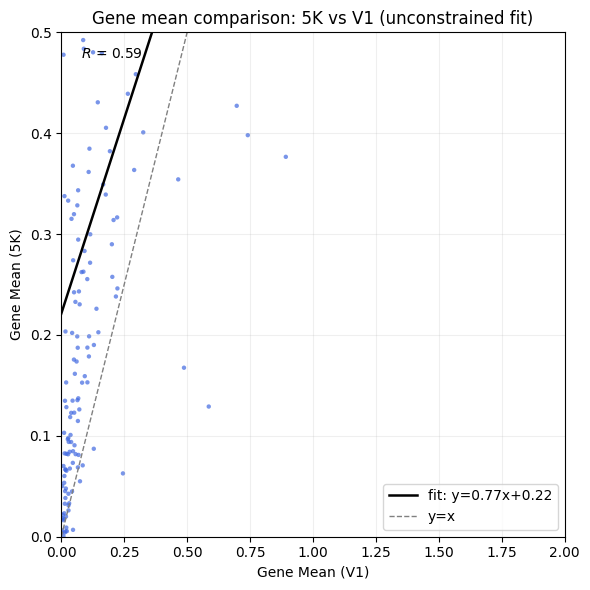

In [179]:
gene_means = pd.DataFrame({
    "mean_counts_5k": adata_5k.var["mean_counts"].astype(float),
    "mean_counts_v1": adata_v1.var.loc[adata_5k.var_names, "mean_counts"].astype(float),
}).dropna()

x = gene_means["mean_counts_v1"].to_numpy()
y = gene_means["mean_counts_5k"].to_numpy()

valid = np.isfinite(x) & np.isfinite(y)
xv = x[valid]
yv = y[valid]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xv, yv, s=10, alpha=0.7, color="royalblue", edgecolors="none")

if xv.size >= 2:
    r, p = pearsonr(xv, yv)

    # Unconstrained linear fit (does not force line through origin)
    m, b = np.polyfit(xv, yv, 1)

    lo = 0.0
    hi = max(np.nanmax(xv), np.nanmax(yv)) * 1.05
    x_line = np.linspace(lo, hi, 200)
    y_fit = m * x_line + b

    ax.plot(x_line, y_fit, color="black", linewidth=1.8, label=f"fit: y={m:.2f}x+{b:.2f}")
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", linewidth=1, label="y=x")

    ax.text(
        0.04,
        0.97,
        f"$R$ = {r:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
    )
    ax.legend(loc="lower right")
else:
    hi = 1.0
    ax.text(0.04, 0.97, "Not enough valid points for correlation", transform=ax.transAxes, va="top")

ax.set_xlim(0.0, 2)
ax.set_ylim(0.0, 0.5)
ax.set_xlabel("Gene Mean (V1)")
ax.set_ylabel("Gene Mean (5K)")
ax.set_title("Gene mean comparison: 5K vs V1 (unconstrained fit)")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

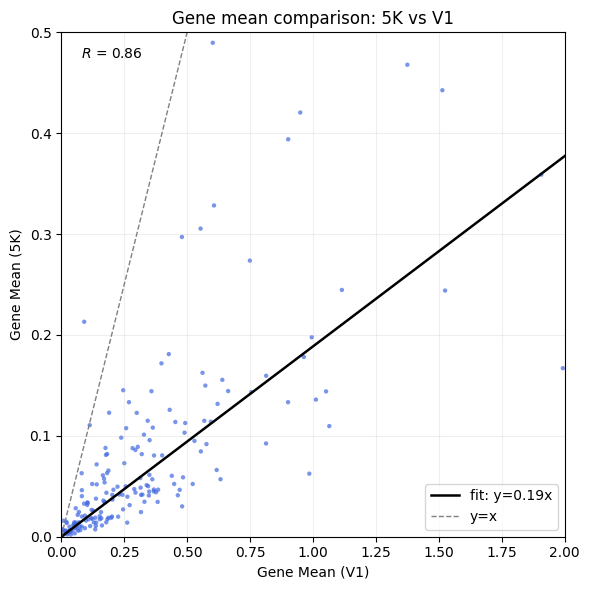

In [155]:
gene_means = pd.DataFrame({
    "mean_counts_5k": adata_5k.var["mean_counts"].astype(float),
    "mean_counts_v1": adata_v1.var.loc[adata_5k.var_names, "mean_counts"].astype(float),
}).dropna()

x = gene_means["mean_counts_v1"].to_numpy()
y = gene_means["mean_counts_5k"].to_numpy()

valid = np.isfinite(x) & np.isfinite(y)
xv = x[valid]
yv = y[valid]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xv, yv, s=10, alpha=0.7, color="royalblue", edgecolors="none")

if xv.size >= 2:
    r, p = pearsonr(xv, yv)

    # Constrained linear fit through origin (starts at 0,0)
    denom = np.dot(xv, xv)
    m = np.dot(xv, yv) / denom if denom > 0 else 0.0

    lo = 0.0
    hi = max(np.nanmax(xv), np.nanmax(yv)) * 1.05
    x_line = np.linspace(lo, hi, 200)
    y_fit = m * x_line

    ax.plot(x_line, y_fit, color="black", linewidth=1.8, label=f"fit: y={m:.2f}x")
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", linewidth=1, label="y=x")

    ax.text(
        0.04,
        0.97,
        f"$R$ = {r:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
    )
    ax.legend(loc="lower right")
else:
    hi = 1.0
    ax.text(0.04, 0.97, "Not enough valid points for correlation", transform=ax.transAxes, va="top")

ax.set_xlim(0.0, 2)
ax.set_ylim(0.0, 0.5)
ax.set_xlabel("Gene Mean (V1)")
ax.set_ylabel("Gene Mean (5K)")
ax.set_title("Gene mean comparison: 5K vs V1")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Finding biggest mean differences
Here we find the top 3 biggest mean differences and top 3 lowest mean differences between genes for the 5K and V1 panel

In [180]:
# Top/bottom 3 genes by mean_counts difference (V1 - 5K)
means = pd.DataFrame({
    "mean_counts_5k": adata_5k.var["mean_counts"],
    "mean_counts_v1": adata_v1.var.loc[adata_5k.var_names, "mean_counts"],
})
means["mean_diff_v1_minus_5k"] = means["mean_counts_v1"] - means["mean_counts_5k"]

# Highest positive differences
high3 = means.sort_values("mean_diff_v1_minus_5k", ascending=False).head(3)
# Most negative differences
low3 = means.sort_values("mean_diff_v1_minus_5k", ascending=True).head(3)

print("Top 3 higher in V1 vs 5K (mean_counts):")
print(high3)
print("\nTop 3 lower in V1 vs 5K (mean_counts):")
print(low3)


Top 3 higher in V1 vs 5K (mean_counts):
      mean_counts_5k  mean_counts_v1  mean_diff_v1_minus_5k
MALL        0.901524        4.559849               3.658325
MET         0.376595        0.892066               0.515472
CFTR        0.129054        0.585891               0.456837

Top 3 lower in V1 vs 5K (mean_counts):
       mean_counts_5k  mean_counts_v1  mean_diff_v1_minus_5k
AGR3         3.600815        0.308100              -3.292714
EPCAM        5.879039        3.150970              -2.728069
IL7R         1.779382        0.317876              -1.461507


### Means of the expressing cells

In [181]:
means_pos = pd.DataFrame(index=adata_5k.var_names)

# Mean among expressing cells (nonzero only)
means_pos["mean_pos_counts_5k"] = (
    adata_5k.var["total_counts"] / adata_5k.var["n_cells_by_counts"].replace(0, np.nan)
).astype(float)

means_pos["mean_pos_counts_v1"] = (
    adata_v1.var["total_counts"] / adata_v1.var["n_cells_by_counts"].replace(0, np.nan)
).astype(float)

means_pos["mean_pos_diff_5k_minus_v1"] = (
    means_pos["mean_pos_counts_5k"] - means_pos["mean_pos_counts_v1"]
)

# Drop genes that are never expressed in either dataset (optional but usually sensible)
means_pos = means_pos.dropna(subset=["mean_pos_counts_5k", "mean_pos_counts_v1"])

high3_pos = means_pos.sort_values("mean_pos_diff_5k_minus_v1", ascending=False).head(3)
low3_pos  = means_pos.sort_values("mean_pos_diff_5k_minus_v1", ascending=True).head(3)

print("Top 3 higher in 5K vs V1 (mean among expressing cells):")
print(high3_pos)

print("\nTop 3 lower in 5K vs V1 (mean among expressing cells):")
print(low3_pos)

Top 3 higher in 5K vs V1 (mean among expressing cells):
        mean_pos_counts_5k  mean_pos_counts_v1  mean_pos_diff_5k_minus_v1
AGR3              9.859938            1.399874                   8.460064
EPCAM            12.457715            4.425747                   8.031967
CXCL10            6.538807            1.895685                   4.643121

Top 3 lower in 5K vs V1 (mean among expressing cells):
      mean_pos_counts_5k  mean_pos_counts_v1  mean_pos_diff_5k_minus_v1
MALL            3.298419            6.063328                  -2.764909
MYC             2.351749            3.061012                  -0.709263
MET             2.209516            2.514622                  -0.305106


### What this plot shows
This plot compares the distribution of expression for selected genes between the **5K** panel and **V1** panel, one gene per row.

For each gene, two histograms are shown:
- **Left column (`all cells`)**: `log1p(raw counts)` across **all cells**, including zeros. This shows both detection frequency (how many zeros) and expression magnitude.
- **Right column (`>0 only`)**: `log1p(raw counts)` using only cells where the gene is detected (`count > 0`). This isolates expression strength among expressing cells.

Additional notes:
- The summary table printed below the plot reports per-gene:
  - `mean_first`, `mean_second`: mean raw counts in 5K and V1 across all cells.
  - `detect_pct_first`, `detect_pct_second`: percentage of cells with nonzero counts in 5K and V1.
- In this implementation, **`first = 5K`** and **`second = V1`**.

Per-gene summary (mean counts + detection %):
 gene  mean_first  mean_second  detect_pct_first  detect_pct_second
 MALL      0.9015       4.5598           27.3320            75.2037
  MET      0.3766       0.8921           17.0442            35.4752
 CFTR      0.1291       0.5859            7.5340            29.6379
 AGR3      3.6008       0.3081           36.5196            22.0092
EPCAM      5.8790       3.1510           47.1920            71.1963
 IL7R      1.7794       0.3179           38.3179            15.9686


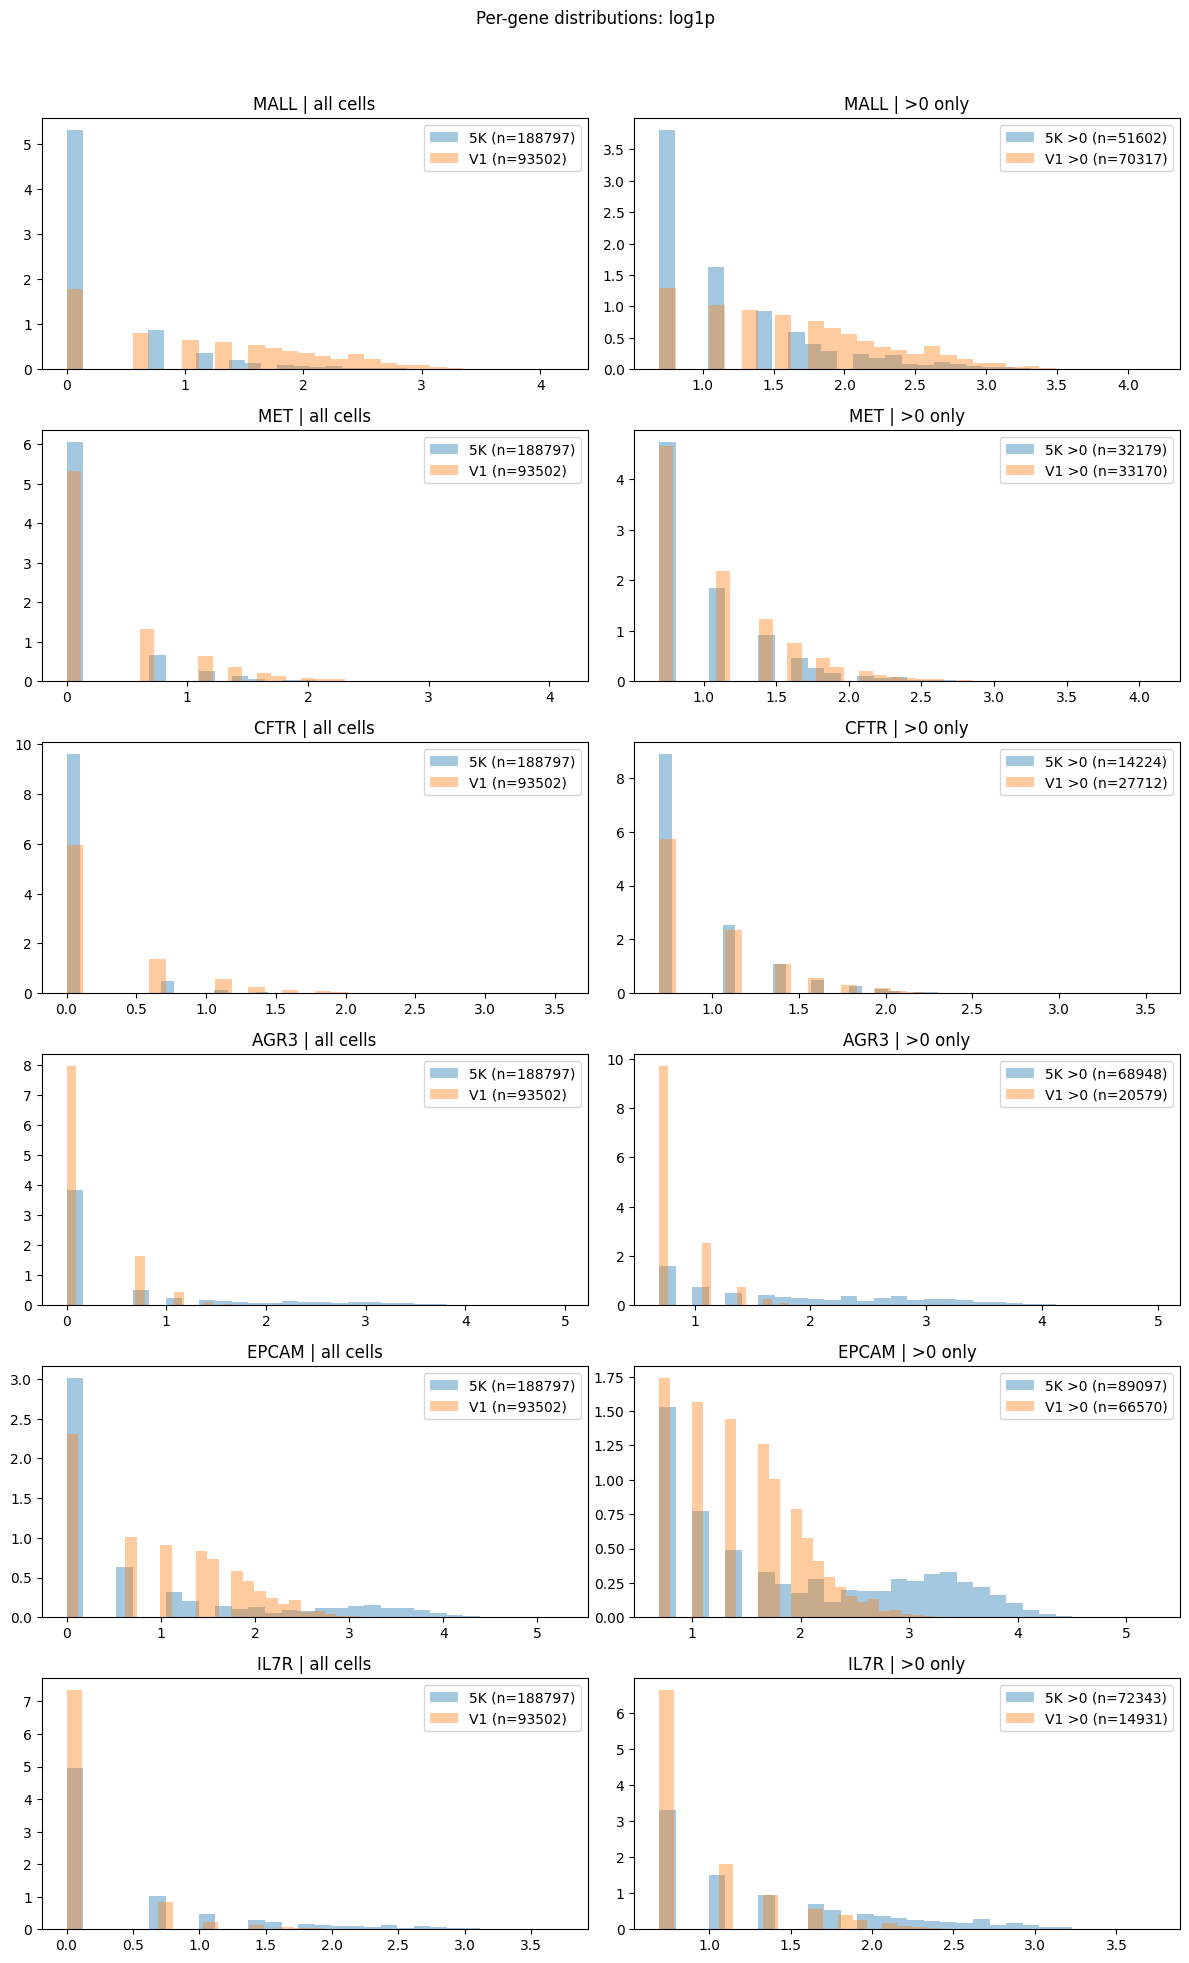

In [182]:
# This helps since we have a very sparse expression matrix, which converts it to an array
def _col_dense(X, j):
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X)[:, j]

# Same thing but for rows
def _row_sums(X):
    if issparse(X):
        return np.ravel(X.sum(axis=1)).astype(float)
    return np.asarray(X).sum(axis=1).astype(float)

def plot_gene_hist_grid(
    adata_5k, adata_v1,
    genes,
    target_sum=1e4,
    bins=30,
    seed=0,
    density=False
):
    X5, Xv = adata_5k.X, adata_v1.X
    tot5, totv = _row_sums(X5), _row_sums(Xv)

    n = len(genes)
    fig, axs = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)

    rng = np.random.default_rng(seed)
    summary_rows = []

    for i, gene in enumerate(genes):
        j5 = adata_5k.var_names.get_loc(gene)
        jv = adata_v1.var_names.get_loc(gene)

        c5 = _col_dense(X5, j5)
        cv = _col_dense(Xv, jv)

        x5_all = np.log1p(c5)
        xv_all = np.log1p(cv)

        # >0 only
        x5_pos = x5_all[c5 > 0]
        xv_pos = xv_all[cv > 0]

        summary_rows.append(
            {
                "gene": gene,
                "mean_first": float(np.mean(c5)),
                "mean_second": float(np.mean(cv)),
                "detect_pct_first": float(np.mean(c5 > 0) * 100),
                "detect_pct_second": float(np.mean(cv > 0) * 100),
            }
        )

        # Left: all cells (zeros included)
        axL = axs[i, 0]
        axL.hist(x5_all, bins=bins, density=density, alpha=0.4, label=f"5K (n={len(x5_all)})")
        axL.hist(xv_all, bins=bins, density=density, alpha=0.4, label=f"V1 (n={len(xv_all)})")
        axL.set_title(f"{gene} | all cells")
        axL.legend()

        # Right: positives only
        axR = axs[i, 1]
        axR.hist(x5_pos, bins=bins, density=density, alpha=0.4, label=f"5K >0 (n={len(x5_pos)})")
        axR.hist(xv_pos, bins=bins, density=density, alpha=0.4, label=f"V1 >0 (n={len(xv_pos)})")
        axR.set_title(f"{gene} | >0 only")
        axR.legend()

    summary_df = pd.DataFrame(summary_rows)
    print("Per-gene summary (mean counts + detection %):")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig.suptitle("Per-gene distributions: log1p", y=1.02)
    plt.tight_layout()
    plt.show()

# Example usage:
genes_to_plot = list(high3.index) + list(low3.index)
plot_gene_hist_grid(adata_5k, adata_v1, genes_to_plot, bins=30, density=True)

In [ ]:
def thin_v1_to_match_5k_binomial(
    adata_v1,
    adata_5k,
    seed=0,
    extra_detection_drop=True,
    drop_mode="low_counts",   # "random" or "low_counts"
    report=True,
):
    if not (adata_v1.var_names == adata_5k.var_names).all():
        raise ValueError("Genes must match and be in the same order (overlap-only).")

    rng = np.random.default_rng(seed)

    # --- Ensure sparse CSC for efficient per-gene operations ---
    Xv = adata_v1.X
    Xv = Xv.tocsc() if sp.issparse(Xv) else sp.csc_matrix(Xv)

    n_cells, n_genes = Xv.shape

    # --- Basic count validity checks ---
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values; expected raw counts.")
        # If floats, require near-integers (common if matrix got cast)
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError(
                    "adata_v1.X looks non-integer. Use raw counts (not normalized/log1p)."
                )

    # --- Compute per-gene means from X directly (more reliable than var fields) ---
    # mean = total / n_cells
    total_v1 = np.asarray(Xv.sum(axis=0)).ravel().astype(np.float64)
    mean_v1 = total_v1 / float(n_cells)

    X5 = adata_5k.X
    X5 = X5.tocsc() if sp.issparse(X5) else sp.csc_matrix(X5)
    total_5k = np.asarray(X5.sum(axis=0)).ravel().astype(np.float64)
    mean_5k = total_5k / float(adata_5k.n_obs)

    # --- Detection targets from 5K: fraction of cells with > 0 ---
    det_tgt = np.asarray((X5 > 0).sum(axis=0)).ravel().astype(np.float64) / float(adata_5k.n_obs)
    k_tgt = np.rint(det_tgt * n_cells).astype(np.int64)

    # --- Per-gene thinning probability ---
    # If mean_v1 == 0 => p=0; if mean_5k > mean_v1 => p=1 (can't increase by thinning).
    with np.errstate(divide="ignore", invalid="ignore"):
        p_gene = np.where(mean_v1 > 0, mean_5k / mean_v1, 0.0)
    p_gene = np.clip(p_gene, 0.0, 1.0).astype(np.float64)

    # --- Binomial thinning on sparse CSC ---
    new_data_chunks = []
    new_indices_chunks = []
    new_indptr = np.zeros(n_genes + 1, dtype=np.int64)
    nnz_so_far = 0

    indptr = Xv.indptr
    indices = Xv.indices
    data = np.rint(Xv.data).astype(np.int64, copy=False)  # safe after near-integer check

    for j in range(n_genes):
        start, end = indptr[j], indptr[j + 1]
        if start == end or p_gene[j] <= 0.0:
            new_indptr[j + 1] = nnz_so_far
            continue

        rows = indices[start:end]
        x = data[start:end]
        p = p_gene[j]

        # Binomial thinning
        if np.isscalar(p):
            x_new = rng.binomial(x, p).astype(np.int64, copy=False)
        else:
            x_new = rng.binomial(x, p).astype(np.int64, copy=False)

        keep = x_new > 0
        if not np.any(keep):
            new_indptr[j + 1] = nnz_so_far
            continue

        rows_k = rows[keep]
        x_k = x_new[keep]

        # Optional: if detection still higher than target, drop some positives
        if extra_detection_drop:
            nnz = rows_k.size
            tgt = int(k_tgt[j])
            if tgt < nnz:
                drop_n = nnz - tgt

                if drop_mode == "random":
                    drop_idx = rng.choice(nnz, size=drop_n, replace=False)
                elif drop_mode == "low_counts":
                    # Prefer dropping low counts (more realistic): probability ∝ 1/(count+eps)
                    w = 1.0 / (x_k.astype(np.float64) + 1e-9)
                    w = w / w.sum()
                    drop_idx = rng.choice(nnz, size=drop_n, replace=False, p=w)
                else:
                    raise ValueError("drop_mode must be 'random' or 'low_counts'.")

                mask2 = np.ones(nnz, dtype=bool)
                mask2[drop_idx] = False
                rows_k = rows_k[mask2]
                x_k = x_k[mask2]

        # Sort rows within column (CSC invariant)
        order = np.argsort(rows_k)
        rows_k = rows_k[order]
        x_k = x_k[order]

        new_indices_chunks.append(rows_k.astype(np.int32, copy=False))
        new_data_chunks.append(x_k.astype(np.int64, copy=False))

        nnz_so_far += rows_k.size
        new_indptr[j + 1] = nnz_so_far

    new_indices = np.concatenate(new_indices_chunks) if new_indices_chunks else np.array([], dtype=np.int32)
    new_data = np.concatenate(new_data_chunks) if new_data_chunks else np.array([], dtype=np.int64)

    X_new_csc = sp.csc_matrix((new_data, new_indices, new_indptr), shape=(n_cells, n_genes))
    X_new = X_new_csc.tocsr()

    adata_ds = adata_v1.copy()
    adata_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_ds, inplace=True, percent_top=None)

    if report:
        det_ds = np.asarray((X_new > 0).sum(axis=0)).ravel() / float(n_cells)
        mean_ds = np.asarray(X_new.sum(axis=0)).ravel() / float(n_cells)

        # Quick summaries
        print("Per-gene mean match (median abs diff):", np.median(np.abs(mean_ds - mean_5k)))
        print("Per-gene det match  (median abs diff):", np.median(np.abs(det_ds - det_tgt)))
        print("Genes where mean_ds > mean_5k (should be rare):", int(np.sum(mean_ds > mean_5k + 1e-9)))
        print("Genes where det_ds  > det_tgt  (should be rare if extra_detection_drop=True):",
              int(np.sum(det_ds > det_tgt + 1e-9)))

    return adata_ds, p_gene

In [184]:
adata_v1_5k_like, p_gene = thin_v1_to_match_5k_binomial(
    adata_v1,
    adata_5k,
    seed=0,
    extra_detection_drop=True,
    drop_mode="low_counts",
    report=True,
)

Per-gene mean match (median abs diff): 0.10129194887833746
Per-gene det match  (median abs diff): 0.02349874906034504
Genes where mean_ds > mean_5k (should be rare): 0
Genes where det_ds  > det_tgt  (should be rare if extra_detection_drop=True): 21


### Downsample V1 with a fixed p (don't need 5k for this anymore)

Fixed p used: 0.19
Median per-gene mean ratio (after/before): 0.18949611089550616
Median per-gene detection ratio (after/before): 0.2383588162858909
AnnData object with n_obs × n_vars = 93502 × 156
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_250_genes', 'pct_counts_in_top_25_genes', 'pct_counts_in_top_150_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


KeyError: 'IFI6'

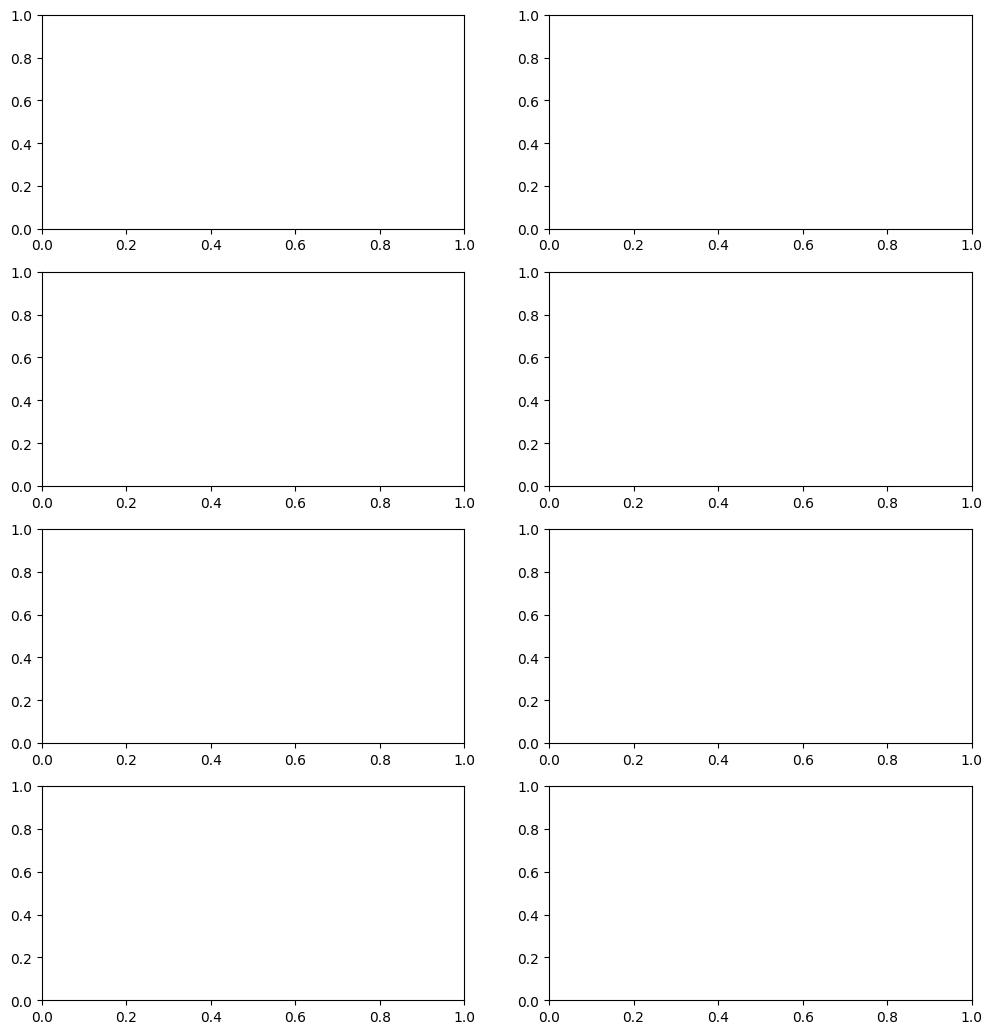

In [ ]:
def downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=0,
    report=True,
):
    p = float(p)
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values; expected raw counts.")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer. Use raw counts (not normalized/log1p).")

    data_int = np.rint(Xv.data).astype(np.int64, copy=False)
    data_new = rng.binomial(data_int, p).astype(np.int64, copy=False)

    # Keep CSR structure consistent, then drop explicit zeros.
    X_new = sp.csr_matrix(
        (data_new, Xv.indices.copy(), Xv.indptr.copy()),
        shape=Xv.shape,
    )
    X_new.eliminate_zeros()

    adata_v1_ds = adata_v1.copy()
    adata_v1_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_v1_ds, inplace=True, percent_top=None)

    if report:
        n_cells = adata_v1_ds.n_obs
        mean_before = np.asarray(Xv.sum(axis=0)).ravel() / float(n_cells)
        mean_after = np.asarray(X_new.sum(axis=0)).ravel() / float(n_cells)
        det_before = np.asarray((Xv > 0).sum(axis=0)).ravel() / float(n_cells)
        det_after = np.asarray((X_new > 0).sum(axis=0)).ravel() / float(n_cells)

        print(f"Fixed p used: {p}")
        print("Median per-gene mean ratio (after/before):", np.median((mean_after + 1e-12) / (mean_before + 1e-12)))
        print("Median per-gene detection ratio (after/before):", np.median((det_after + 1e-12) / (det_before + 1e-12)))

    return adata_v1_ds


# Example usage
adata_v1_019 = downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=0,
    report=True,
)
print(adata_v1_019)

plot_gene_hist_grid(adata_v1, adata_v1_019, plot_genes, bins=30, density=True)

Per-gene summary (mean counts + detection %):
 gene  mean_first  mean_second  detect_pct_first  detect_pct_second
 MALL      0.9015       0.6169           27.3320            27.3320
  MET      0.3766       0.3084           17.0442            17.0446
 CFTR      0.1291       0.0965            7.5340             7.5335
 AGR3      3.6008       0.3081           36.5196            22.0092
EPCAM      5.8790       2.4602           47.1920            47.1915
 IL7R      1.7794       0.3179           38.3179            15.9686


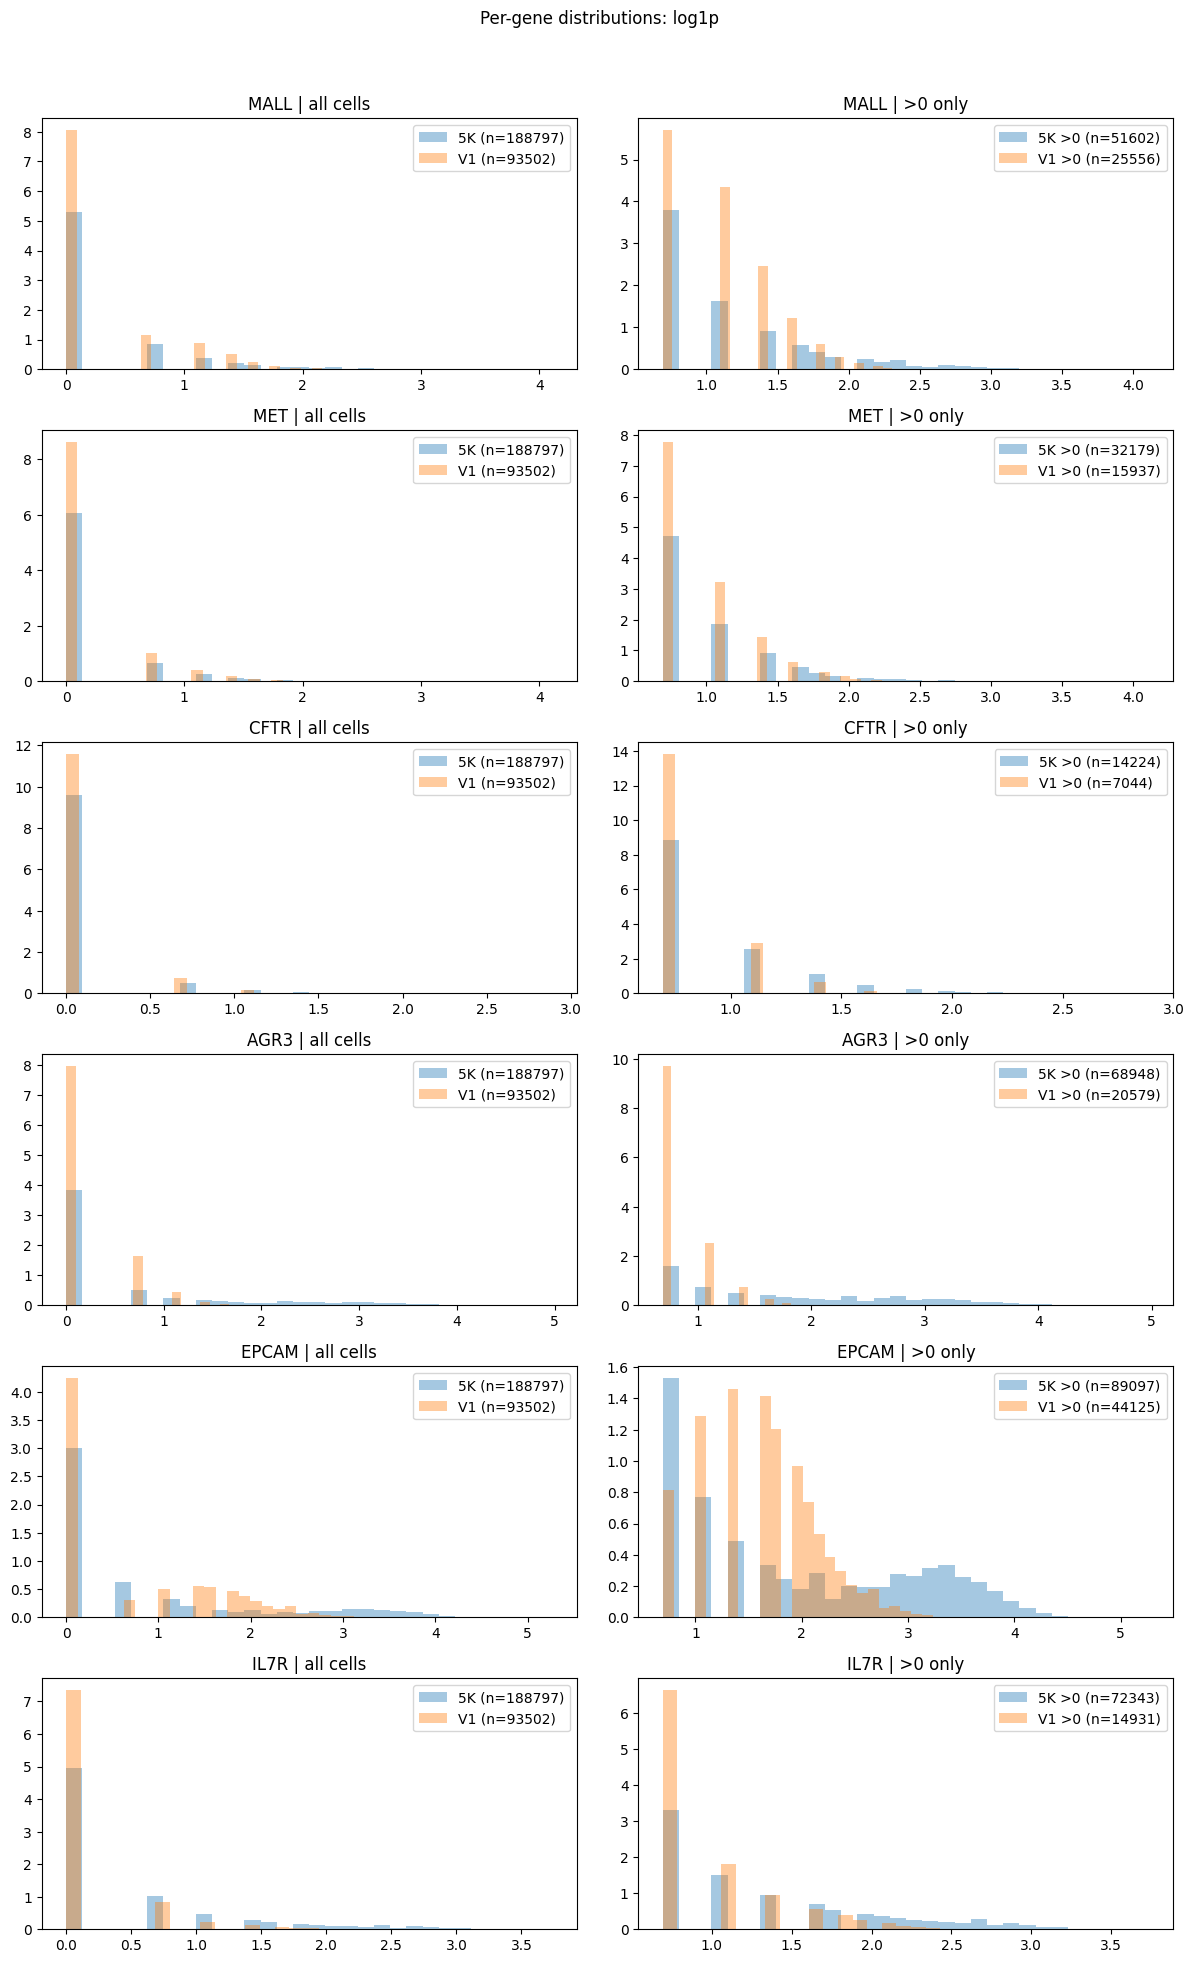

In [186]:
genes_to_plot = list(high3.index) + list(low3.index)
plot_gene_hist_grid(adata_5k, adata_v1_5k_like , genes_to_plot, bins=30, density=True)

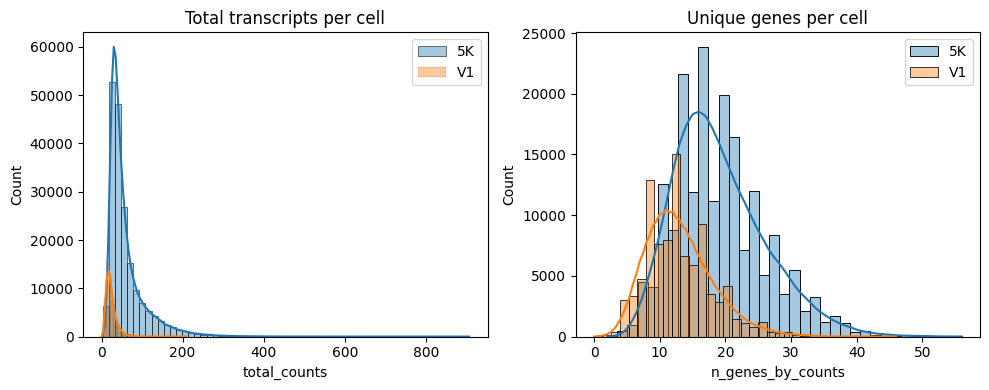

In [187]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 1) Total transcripts per cell
axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata_5k.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[0],
)
sns.histplot(
    adata_v1_5k_like.obs["total_counts"],
    kde=True,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[0],
)
axs[0].legend()

# 2) Unique genes per cell
axs[1].set_title("Unique genes per cell")
sns.histplot(
    adata_5k.obs["n_genes_by_counts"],
    kde=True,
    
    bins=35,
    alpha=0.4,
    label="5K",
    ax=axs[1],
)
sns.histplot(
    adata_v1_5k_like.obs["n_genes_by_counts"],
    kde=True,
    bins=35,
    alpha=0.4,
    label="V1",
    ax=axs[1],
)
axs[1].legend()

plt.tight_layout()
plt.show()

In [200]:
adata_5k

AnnData object with n_obs × n_vars = 198031 × 278
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_25_genes', 'pct_counts_in_top_150_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\2400364743.py:56: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\2400364743.py:56: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_25336\2400364743.py:56: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)


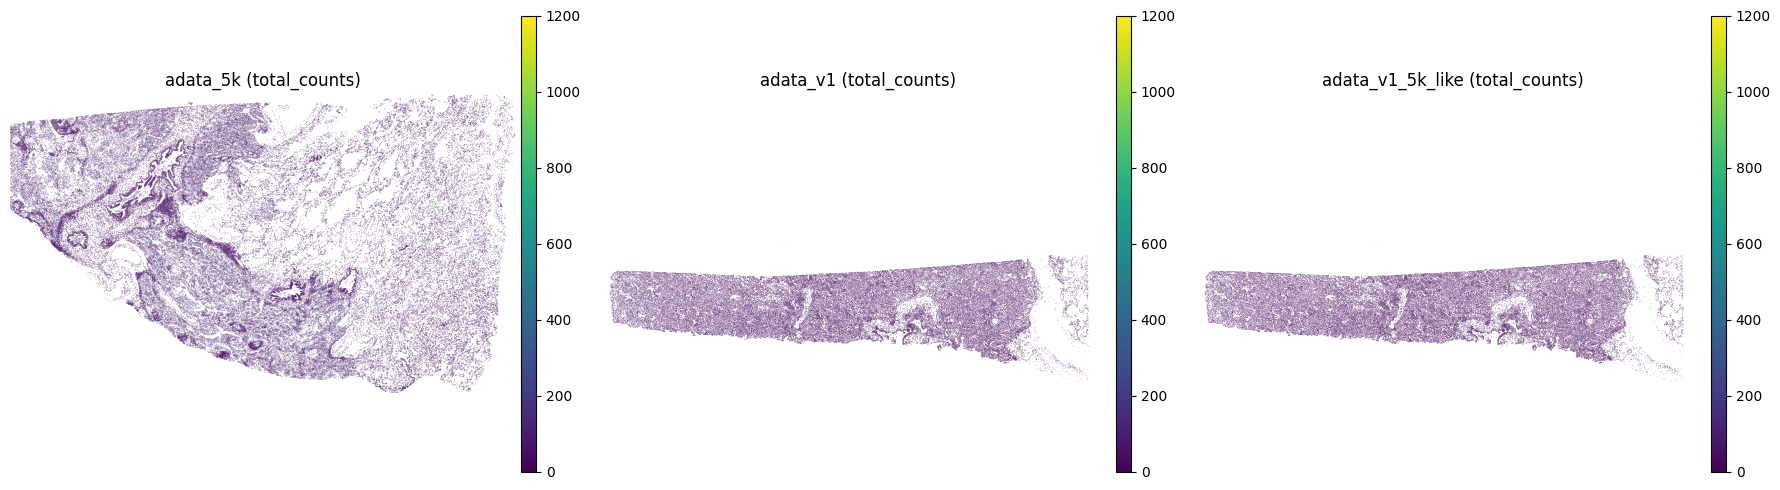

In [188]:
# Combined spatial plots (shared axes + shared color scale)
def _ensure_spatial_coords(adata):
    if "spatial" in adata.obsm:
        return
    candidate_pairs = [
        ("x_centroid", "y_centroid"),
        ("x", "y"),
        ("center_x", "center_y"),
        ("centroid_x", "centroid_y"),
        ("global_x", "global_y"),
    ]
    pair = next(
        ((x, y) for x, y in candidate_pairs if x in adata.obs.columns and y in adata.obs.columns),
        None,
    )
    if pair is None:
        raise KeyError(
            "No spatial coordinates found. Expected adata.obsm['spatial'] or one of: "
            f"{candidate_pairs}."
        )
    adata.obsm["spatial"] = adata.obs[[pair[0], pair[1]]].to_numpy()

plot_adatas = [adata_5k, adata_v1, adata_v1_5k_like]
plot_titles = ["adata_5k", "adata_v1", "adata_v1_5k_like"]

for adata in plot_adatas:
    _ensure_spatial_coords(adata)

shared_candidates = ["leiden", "total_counts", "n_genes_by_counts"]
shared_color_key = next(
    (k for k in shared_candidates if all(k in adata.obs.columns for adata in plot_adatas)),
    None,
)

xy_all = np.vstack([np.asarray(adata.obsm["spatial"], dtype=float) for adata in plot_adatas])
shared_xlim = (float(np.nanmin(xy_all[:, 0])), float(np.nanmax(xy_all[:, 0])))
shared_ylim = (float(np.nanmin(xy_all[:, 1])), float(np.nanmax(xy_all[:, 1])))

shared_vrange = None
if shared_color_key is not None and all(pd.api.types.is_numeric_dtype(adata.obs[shared_color_key]) for adata in plot_adatas):
    c_all = np.concatenate([
        adata.obs[shared_color_key].to_numpy(dtype=float)
        for adata in plot_adatas
    ])
    shared_vrange = (float(np.nanmin(c_all)), 1200) # float(np.nanmax(c_all))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, adata, title in zip(axs, plot_adatas, plot_titles):
    kwargs = dict(ax=ax, spot_size=10, frameon=False, show=False)
    if shared_color_key is not None:
        kwargs["color"] = shared_color_key
    if shared_vrange is not None:
        kwargs["vmin"], kwargs["vmax"] = shared_vrange

    sc.pl.spatial(adata, **kwargs)
    ax.set_xlim(shared_xlim)
    ax.set_ylim(shared_ylim)
    ax.set_aspect("equal")
    ax.set_title(f"{title} ({shared_color_key or 'no color'})")

plt.tight_layout()
plt.show()

## 4) Spatial Scattering (Leiden)

#### Spatial Scattering 5K panel

In [34]:
adata_5k_clust = adata_5k.copy()
sc.pp.normalize_total(adata_5k_clust, inplace=True)
sc.pp.log1p(adata_5k_clust)
sc.pp.pca(adata_5k_clust, n_comps=30)
sc.pp.neighbors(adata_5k_clust, n_neighbors=40, n_pcs=20)
# sc.tl.umap(adata_5k_clust)
sc.tl.leiden(adata_5k_clust, resolution=0.3)

C:\Users\ntpar\AppData\Local\Temp\ipykernel_12416\1654453075.py:2: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_5k_clust, inplace=True)


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


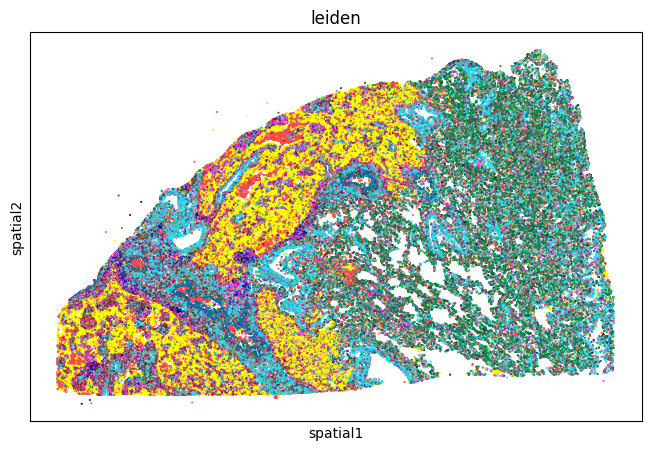

In [36]:
sq.pl.spatial_scatter(
    adata_5k_clust,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    legend_loc=None,
    wspace=0.4,
)

#### Spatial Scattering downsampled custom panel

In [29]:
adata_5k_like_clust = adata_v1_5k_like.copy()
sc.pp.normalize_total(adata_5k_like_clust, inplace=True)
sc.pp.log1p(adata_5k_like_clust)
sc.pp.pca(adata_5k_like_clust, n_comps=30)
sc.pp.neighbors(adata_5k_like_clust, n_neighbors=40, n_pcs=20)
sc.tl.leiden(adata_5k_like_clust, resolution=0.3)

C:\Users\ntpar\AppData\Local\Temp\ipykernel_12416\2870292144.py:2: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_5k_like_clust, inplace=True)


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


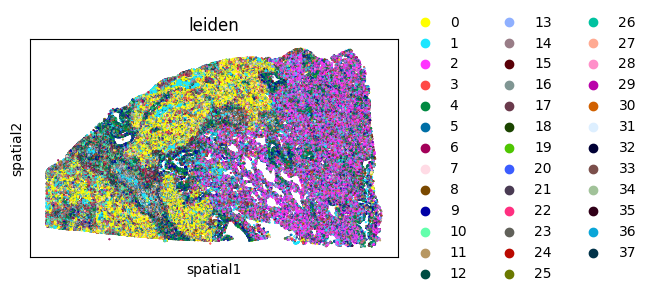

In [30]:
sq.pl.spatial_scatter(
    adata_5k_like_clust,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    wspace=0.4,
)

#### Spatial scattering custom panel

In [31]:
adata_v1_clust = adata_v1.copy()
sc.pp.normalize_total(adata_v1_clust, inplace=True)
sc.pp.log1p(adata_v1_clust)
sc.pp.pca(adata_v1_clust)
sc.pp.neighbors(adata_v1_clust)
sc.tl.leiden(adata_v1_clust)

C:\Users\ntpar\AppData\Local\Temp\ipykernel_12416\1877317822.py:2: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_v1_clust, inplace=True)


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


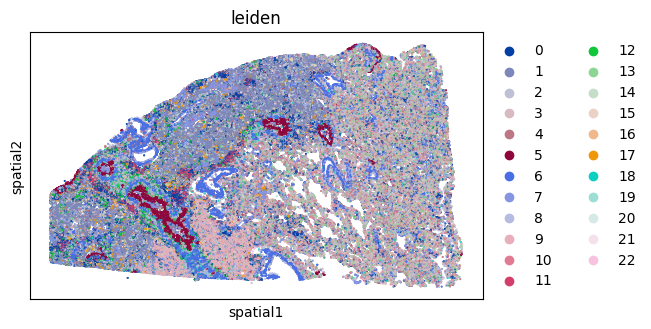

In [32]:
sq.pl.spatial_scatter(
    adata_v1_clust,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    wspace=0.4,
)